# Methanol & Pig Iron Cost Optimization Case Study


This notebook adapts the original methanol and pig iron example for the new economic cost objective in `optimex`.


It keeps the same foreground system and premise background databases, but adds illustrative `market_price` attributes to the time-specific background nodes before the LCA processor is run.


The goal is an end-to-end technical check of the economics pipeline:


- write prices to background nodes

- extract and interpolate them in `LCADataProcessor`

- pass them into `OptimizationModelInputs`

- solve with `objective="cost"`.


**Prerequisites**: ecoinvent 3.12 + premise databases must be set up as in the original notebook.

<div style="display: flex; background-color: white; border-radius: 15px; padding: 10px; width: 100%; max-width: 800px; margin: 0 auto;">
  <img src="data/product_system.svg" style="border-radius: 15px; width: 100%;">
</div>

In [1]:
import bw2data as bd

bd.projects.set_current("optimex_remind")

c:\Users\lucal\Brightway\optimex\.venv\Lib\site-packages\bw2calc\__init__.py:57: UserWarning: No fast sparse solver found
  warnings.warn("No fast sparse solver found")
c:\Users\lucal\Brightway\optimex\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


## Background Inputs from ecoinvent/premise

Retrieve background processes (electricity, heat, water, infrastructure, raw materials) and biosphere flows from the premise-modified ecoinvent databases.


In [2]:
electricity_mv = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="market group for electricity, medium voltage",
    location="RER",
)
electricity_lv = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="market group for electricity, low voltage",
    location="RER",
)
heat = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="market for heat, district or industrial",
    location="DEU",
)  # Process not available for RER
water_tap = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="market for tap water",
    location="Europe without Switzerland",
)
water_deionized = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="deionized water production, via reverse osmosis, from brackish water",
    location="RER",
)

dac_system = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="direct air capture system, solvent-based, 1MtCO2",
    location="RER",
)
dac_system_eol = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="treatment of direct air capture system, solvent-based, 1MtCO2",
    location="RER",
)

pem_stack = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="electrolyzer production, 1MWe, PEM, Stack",
    location="RER",
)
pem_stack_eol = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="treatment of electrolyzer stack, 1MWe, PEM",
    location="RER",
)
pem_bop = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="electrolyzer production, 1MWe, PEM, Balance of Plant",
    location="RER",
)
pem_bop_eol = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="treatment of electrolyzer balance of plant, 1MWe, PEM",
    location="RER",
)

methanol_production_facility = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="methanol production facility, construction",
    location="RER",
)

blast_furnace_production = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="market for blast furnace",
    location="GLO",
)
coke = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020", name="market for coke", location="RoW"
)
hard_coal = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="market group for hard coal",
    location="RER",
)
iron_ore_concentrate = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="market for iron ore concentrate",
    location="World",
)
iron_sinter = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="iron sinter production",
    location="RER",
)
iron_pellet = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="market for iron pellet",
    location="GLO",
)
natural_gas = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="petroleum and gas production, offshore",
    product="natural gas, high pressure",
    location="DE",
)

methanol_factory_ng = bd.get_node(
    database="ei312_REMIND-EU_SSP2_NDC_2020",
    name="market for methanol factory",
    location="GLO",
)

In [3]:
co2 = bd.get_node(
    database="ecoinvent-3.12-biosphere",
    name="Carbon dioxide, fossil",
    categories=("air",),
)

particulate_matter_sm = bd.get_node(
    database="ecoinvent-3.12-biosphere",
    name="Particulate Matter, < 2.5 um",
    categories=("air",),
)
particulate_matter_md = bd.get_node(
    database="ecoinvent-3.12-biosphere",
    name="Particulate Matter, > 2.5 um and < 10um",
    categories=("air",),
)
particulate_matter_lg = bd.get_node(
    database="ecoinvent-3.12-biosphere",
    name="Particulate Matter, > 10 um",
    categories=("air",),
)

## Foreground Setup

Define the decision-relevant foreground system. Each process has:

- **`operation_time_limits`**: when the operation phase occurs within the process lifetime
- **`operation=True`** on exchanges that scale with operational level
- **`vintage_improvements`**: efficiency gains for processes installed in later years
- Construction and end-of-life exchanges with appropriate temporal distributions

Helper functions (`infer_operation_td_from_limits`, etc.) automatically generate temporal distributions from the operation time limits.


In [4]:
if "foreground" in bd.databases:
    del bd.databases["foreground"]  # to make sure we create the foreground from scratch
foreground = bd.Database("foreground")
foreground.register()

### Products

Four products in the system: methanol and pig iron (final demand), hydrogen and captured CO2 (intermediates).


In [5]:
methanol = foreground.new_node(
    name="methanol",
    code="methanol",
    unit="kg",
    type=bd.labels.product_node_default,
)
methanol.save()

iron = foreground.new_node(
    name="pig iron",
    code="pig iron",
    unit="kg",
    type=bd.labels.product_node_default,
)
iron.save()

hydrogen = foreground.new_node(
    name="hydrogen",
    code="hydrogen",
    unit="kg",
    type=bd.labels.product_node_default,
)
hydrogen.save()

captured_co2 = foreground.new_node(
    name="captured CO2",
    code="captured CO2",
    unit="kg",
    type=bd.labels.product_node_default,
)
captured_co2.save()

### Processes


In [6]:
from optimex.utils import (
    infer_operation_td_from_limits,
    infer_construction_td_from_limits,
    infer_eol_td_from_limits,
)

#### Direct Air Capture (DAC)

Solvent-based DAC producing captured CO2. 15-year operation lifetime. Electricity and heat consumption improve with vintage year.


In [7]:
dac = foreground.new_node(
    name="direct air carbon capture",
    code="direct air carbon capture",
    location="RER",
    type=bd.labels.process_node_default,
    operation_time_limits=(0, 15),
)
dac.save()

In [8]:
# operation
dac.new_edge(
    input=captured_co2,
    amount=1.0,
    type=bd.labels.production_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(dac),
).save()

dac.new_edge(
    input=electricity_mv,
    amount=0.345,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(dac),
).save()

dac.new_edge(
    input=heat,
    amount=6.28,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(dac),
).save()

dac.new_edge(
    input=water_tap,
    amount=3.437,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(dac),
).save()

dac.new_edge(
    input=co2,
    amount=-1.0,
    type=bd.labels.biosphere_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(dac),
).save()

# construction
dac.new_edge(
    input=dac_system,
    amount=5e-11,  # 5e-11
    type=bd.labels.consumption_edge_default,
    temporal_distribution=infer_construction_td_from_limits(dac),
).save()

# end-of-life
dac.new_edge(
    input=dac_system_eol,
    amount=-5e-11,  # 5e-11
    type=bd.labels.consumption_edge_default,
    temporal_distribution=infer_eol_td_from_limits(dac),
).save()

#### PEM Electrolysis

Produces hydrogen from electricity and water. 8-year stack lifetime. Electricity consumption improves with vintage.


In [9]:
pem = foreground.new_node(
    name="PEM Electrolysis",
    code="PEM Electrolysis",
    location="RER",
    type=bd.labels.process_node_default,
    operation_time_limits=(0, 8),
)
pem.save()

In [10]:
# operation
pem.new_edge(
    input=hydrogen,
    amount=1.0,
    type=bd.labels.production_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(pem),
).save()

pem.new_edge(
    input=electricity_lv,
    amount=54,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(pem),
).save()

pem.new_edge(
    input=water_deionized,
    amount=14,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(pem),
).save()

# construction
pem.new_edge(
    input=pem_stack,
    amount=1.34989e-6,
    type=bd.labels.consumption_edge_default,
    temporal_distribution=infer_construction_td_from_limits(pem),
).save()

pem.new_edge(
    input=pem_bop,
    amount=3.37373e-7,
    type=bd.labels.consumption_edge_default,
    temporal_distribution=infer_construction_td_from_limits(pem),
).save()

# end-of-life
pem.new_edge(
    input=pem_stack_eol,
    amount=-1.34989e-6,
    type=bd.labels.consumption_edge_default,
    temporal_distribution=infer_eol_td_from_limits(pem),
).save()

pem.new_edge(
    input=pem_bop_eol,
    amount=-3.37373e-7,
    type=bd.labels.consumption_edge_default,
    temporal_distribution=infer_eol_td_from_limits(pem),
).save()

#### CO2 Hydrogenation to Methanol

Green methanol route: combines hydrogen and captured CO2. 15-year lifetime. Electricity consumption and CO2 emissions improve with vintage.


In [11]:
co2_hydrogenation = foreground.new_node(
    name="Carbon dioxide hydrogenation to methanol",
    code="Carbon dioxide hydrogenation to methanol",
    location="RER",
    type=bd.labels.process_node_default,
    operation_time_limits=(0, 15),
)
co2_hydrogenation.save()

In [12]:
# operation
co2_hydrogenation.new_edge(
    input=methanol,
    amount=1.0,
    type=bd.labels.production_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(co2_hydrogenation),
).save()

co2_hydrogenation.new_edge(
    input=hydrogen,
    amount=0.138975,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(co2_hydrogenation),
).save()

co2_hydrogenation.new_edge(
    input=captured_co2,
    amount=1.690523,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(co2_hydrogenation),
).save()

co2_hydrogenation.new_edge(
    input=electricity_lv,
    amount=0.302895,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(co2_hydrogenation),
).save()

co2_hydrogenation.new_edge(
    input=water_tap,
    amount=0.81959,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(co2_hydrogenation),
).save()

co2_hydrogenation.new_edge(
    input=co2,
    amount=0.32,
    type=bd.labels.biosphere_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(co2_hydrogenation),
).save()

# construction
co2_hydrogenation.new_edge(
    input=methanol_production_facility,
    amount=12.89,
    type=bd.labels.consumption_edge_default,
    temporal_distribution=infer_construction_td_from_limits(co2_hydrogenation),
).save()

#### Blast Furnace with Carbon Capture

Conventional iron production with post-combustion CO2 capture. Co-produces pig iron and captured CO2. 25-year lifetime. PM emissions reduced by 50% through co-capture.


In [13]:
blast_furnace_cc = foreground.new_node(
    name="Blast furnace with carbon capture",
    code="Blast furnace with carbon capture",
    location="RER",
    type=bd.labels.process_node_default,
    operation_time_limits=(0, 25),
)
blast_furnace_cc.save()

In [14]:
total_co2_emission_per_kg_iron = 0.849
captured_co2_per_kg_iron = 0.7054  # Happrecht et al., 2025, SI Section 1.3.2
total_pm_sm_emission_per_kg_iron = 2.8723e-5
total_pm_md_emission_per_kg_iron = 1.5957e-6
total_pm_lg_emission_per_kg_iron = 1.5957e-6
pm_emission_reduction = (
    0.5  # PM reduction through co-capture, Choi, 2013; Singh et al., 2011
)

# operation
blast_furnace_cc.new_edge(
    input=iron,
    amount=1.0,
    type=bd.labels.production_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace_cc),
).save()

blast_furnace_cc.new_edge(
    input=captured_co2,
    amount=captured_co2_per_kg_iron,
    type=bd.labels.production_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace_cc),
).save()

blast_furnace_cc.new_edge(
    input=co2,
    amount=total_co2_emission_per_kg_iron - captured_co2_per_kg_iron,
    type=bd.labels.biosphere_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace_cc),
).save()

blast_furnace_cc.new_edge(
    input=natural_gas,
    amount=2.71 / 36,  # Happrecht et al., 2025, SI Section 1.3.2 w/ 36 MJ/m3
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace_cc),
).save()

blast_furnace_cc.new_edge(
    input=coke,
    amount=9.724,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace_cc),
).save()

blast_furnace_cc.new_edge(
    input=hard_coal,
    amount=0.15,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace_cc),
).save()

blast_furnace_cc.new_edge(
    input=iron_ore_concentrate,
    amount=0.15,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace_cc),
).save()

blast_furnace_cc.new_edge(
    input=iron_pellet,
    amount=0.4,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace_cc),
).save()

blast_furnace_cc.new_edge(
    input=iron_sinter,
    amount=1.05,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace_cc),
).save()

blast_furnace_cc.new_edge(
    input=particulate_matter_sm,
    amount=(1 - pm_emission_reduction) * total_pm_sm_emission_per_kg_iron,
    type=bd.labels.biosphere_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace_cc),
).save()

blast_furnace_cc.new_edge(
    input=particulate_matter_md,
    amount=(1 - pm_emission_reduction) * total_pm_md_emission_per_kg_iron,
    type=bd.labels.biosphere_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace_cc),
).save()

blast_furnace_cc.new_edge(
    input=particulate_matter_lg,
    amount=(1 - pm_emission_reduction) * total_pm_lg_emission_per_kg_iron,
    type=bd.labels.biosphere_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace_cc),
).save()

# construction
blast_furnace_cc.new_edge(
    input=blast_furnace_production,
    amount=1.333e-11,
    type=bd.labels.consumption_edge_default,
    temporal_distribution=infer_construction_td_from_limits(blast_furnace_cc),
).save()

#### Blast Furnace (conventional)

Standard blast furnace without carbon capture. Same inputs as above but full CO2 and PM emissions. 25-year lifetime.


In [15]:
blast_furnace = foreground.new_node(
    name="Blast furnace",
    code="Blast furnace",
    location="RER",
    type=bd.labels.process_node_default,
    operation_time_limits=(0, 25),
)
blast_furnace.save()

In [16]:
# operation
blast_furnace.new_edge(
    input=iron,
    amount=1.0,
    type=bd.labels.production_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace),
).save()

blast_furnace.new_edge(
    input=co2,
    amount=total_co2_emission_per_kg_iron,
    type=bd.labels.biosphere_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace),
).save()

blast_furnace.new_edge(
    input=natural_gas,
    amount=2.71 / 36,  # Happrecht et al., 2025, SI Section 1.3.2 w/ 36 MJ/m3
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace),
).save()

blast_furnace.new_edge(
    input=coke,
    amount=9.724,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace),
).save()

blast_furnace.new_edge(
    input=hard_coal,
    amount=0.15,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace),
).save()

blast_furnace.new_edge(
    input=iron_ore_concentrate,
    amount=0.15,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace),
).save()

blast_furnace.new_edge(
    input=iron_pellet,
    amount=0.4,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace),
).save()

blast_furnace.new_edge(
    input=iron_sinter,
    amount=1.05,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace),
).save()

blast_furnace.new_edge(
    input=particulate_matter_sm,
    amount=total_pm_sm_emission_per_kg_iron,
    type=bd.labels.biosphere_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace),
).save()

blast_furnace.new_edge(
    input=particulate_matter_md,
    amount=total_pm_md_emission_per_kg_iron,
    type=bd.labels.biosphere_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace),
).save()

blast_furnace.new_edge(
    input=particulate_matter_lg,
    amount=total_pm_lg_emission_per_kg_iron,
    type=bd.labels.biosphere_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(blast_furnace),
).save()

# construction
blast_furnace.new_edge(
    input=blast_furnace_production,
    amount=1.333e-11,
    type=bd.labels.consumption_edge_default,
    temporal_distribution=infer_construction_td_from_limits(blast_furnace),
).save()

#### Direct Reduction of Iron (H2-DRI)

Hydrogen-based iron reduction with much lower direct CO2 emissions. Consumes hydrogen, iron pellets, natural gas, and electricity. 25-year lifetime.


In [17]:
direct_reduction = foreground.new_node(
    name="Direct reduction of iron",
    code="Direct reduction of iron",
    location="RER",
    type=bd.labels.process_node_default,
    operation_time_limits=(0, 25),
)
direct_reduction.save()

In [18]:
dri_h2_consumption = 0.06264
dri_iron_pellet_consumption = 1.359733

# operation
direct_reduction.new_edge(
    input=iron,
    amount=1.0,
    type=bd.labels.production_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(direct_reduction),
).save()

direct_reduction.new_edge(
    input=co2,
    amount=0.03271,
    type=bd.labels.biosphere_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(direct_reduction),
).save()

direct_reduction.new_edge(
    input=hydrogen,
    amount=dri_h2_consumption,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(direct_reduction),
).save()

direct_reduction.new_edge(
    input=natural_gas,
    amount=0.0358938,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(direct_reduction),
).save()

direct_reduction.new_edge(
    input=iron_pellet,
    amount=dri_iron_pellet_consumption,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(direct_reduction),
).save()

direct_reduction.new_edge(
    input=electricity_mv,
    amount=0.0192446
    + dri_h2_consumption * 4.024497
    + dri_iron_pellet_consumption * 0.27267,  # incl. h2 and iron pellet preheating
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(direct_reduction),
).save()

# construction
direct_reduction.new_edge(
    input=blast_furnace_production,
    amount=1.333e-11,
    type=bd.labels.consumption_edge_default,
    temporal_distribution=infer_construction_td_from_limits(direct_reduction),
).save()

#### Natural Gas Reforming to Methanol

Conventional methanol production from natural gas. 25-year lifetime. No vintage improvements.


In [19]:
ng_reforming = foreground.new_node(
    name="Natural gas reforming",
    code="Natural gas reforming",
    location="RER",
    type=bd.labels.process_node_default,
    operation_time_limits=(0, 25),
)
ng_reforming.save()

In [20]:
# operation
ng_reforming.new_edge(
    input=methanol,
    amount=1.0,
    type=bd.labels.production_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(ng_reforming),
).save()

ng_reforming.new_edge(
    input=co2,
    amount=0.33424,
    type=bd.labels.biosphere_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(ng_reforming),
).save()


ng_reforming.new_edge(
    input=natural_gas,
    amount=0.8895,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(ng_reforming),
).save()

ng_reforming.new_edge(
    input=water_deionized,
    amount=0.355,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(ng_reforming),
).save()

ng_reforming.new_edge(
    input=electricity_mv,
    amount=0.0886,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(ng_reforming),
).save()

# construction
ng_reforming.new_edge(
    input=methanol_factory_ng,
    amount=3.716e-11,
    type=bd.labels.consumption_edge_default,
    temporal_distribution=infer_construction_td_from_limits(ng_reforming),
).save()

## Optimex Setup

Configure the LCA processing and prepare optimization inputs. This involves:

1. Registering premise background databases with their representative years
2. Defining time-varying demand for methanol and pig iron
3. Selecting impact categories (climate change with CRF, particulate matter, land use, water use)
4. Running the LCA data processor to extract all tensors


### Background Databases and Demand

Register premise databases (2020-2100) with their representative times, then define constant demand of 1 Mt/year for both methanol and pig iron from 2025 to 2050.


In [21]:
from datetime import datetime

dbs = {
    2020: bd.Database("ei312_REMIND-EU_SSP2_NDC_2020"),
    2030: bd.Database("ei312_REMIND-EU_SSP2_NDC_2030"),
    2040: bd.Database("ei312_REMIND-EU_SSP2_NDC_2040"),
    2050: bd.Database("ei312_REMIND-EU_SSP2_NDC_2050"),
    2075: bd.Database("ei312_REMIND-EU_SSP2_NDC_2075"),
    2100: bd.Database("ei312_REMIND-EU_SSP2_NDC_2100"),
}

# Add representative_time metadata for each database
for year, db in dbs.items():
    db.metadata["representative_time"] = datetime(year, 1, 1).isoformat()

In [22]:
from bw_temporalis import TemporalDistribution
import numpy as np

years = range(2025, 2051)
rng = np.random.default_rng(25)

# methanol demand
trend_meoh = np.linspace(1, 1, len(years))
# noise_meoh = rng.normal(0, 4.0, len(years))
noise_meoh = rng.normal(0, 0, len(years))
amount_meoh = trend_meoh + noise_meoh

td_methanol = TemporalDistribution(
    date=np.array(
        [datetime(year, 1, 1).isoformat() for year in years],
        dtype="datetime64[s]",
    ),
    amount=amount_meoh * 1e6,  # Mt scale
)

# iron demand
trend_iron = np.linspace(1, 1, len(years))
# noise_iron = rng.normal(0, 8.0, len(years))
noise_iron = rng.normal(0, 0, len(years))
amount_iron = trend_iron + noise_iron

td_iron = TemporalDistribution(
    date=np.array(
        [datetime(year, 1, 1).isoformat() for year in years],
        dtype="datetime64[s]",
    ),
    amount=amount_iron * 1e6,  # Mt scale
)

functional_demand = {methanol: td_methanol, iron: td_iron}

In [23]:
method_climate_change = ("IPCC 2021", "climate change", "GWP 100a, incl. H and bio CO2")

method_land_use = (
    "ecoinvent-3.12",
    "EF v3.1 no LT",
    "land use no LT",
    "soil quality index no LT",
)

method_particulate_matter = (
    "ecoinvent-3.12",
    "EF v3.1 no LT",
    "particulate matter formation no LT",
    "impact on human health no LT",
)

method_water_use = (
    "ecoinvent-3.12",
    "EF v3.1 no LT",
    "water use no LT",
    "user deprivation potential (deprivation-weighted water consumption) no LT",
)

In [24]:
from optimex import lca_processor

lca_config = lca_processor.LCAConfig(
    demand=functional_demand,
    temporal={
        "start_date": datetime(2020, 1, 1),
        "temporal_resolution": "year",
        "time_horizon": 100,
    },
    characterization_methods=[
        {
            "category_name": "climate_change",
            "brightway_method": method_climate_change,
            "metric": "CRF",  # CRF
        },
        {
            "category_name": "particulate_matter",
            "brightway_method": method_particulate_matter,
        },
        {
            "category_name": "land_use",
            "brightway_method": method_land_use,
        },
        {
            "category_name": "water_use",
            "brightway_method": method_water_use,
        },
    ],
)

### Economic Price Assumptions

The following cell writes illustrative market prices to the time-specific background nodes. Prices are attached to the background activities themselves via `node["market_price"]`, not to foreground edges.

For this case-study notebook, nodes are matched by their stable Brightway `code` across the premise databases. This mirrors the way `LCADataProcessor` later maps the 2020 foreground references to the time-specific background databases.

In [25]:
import pandas as pd
from optimex.economics import set_market_prices

background_databases = {year: db.name for year, db in dbs.items()}
price_years = sorted(background_databases)


def price_trend(start, end):
    """Linear illustrative price trend over the premise background years."""
    values = np.interp(price_years, [price_years[0], price_years[-1]], [start, end])
    return dict(zip(price_years, values))


price_assumptions = [
    {"label": "electricity_mv", "node": electricity_mv, "prices": price_trend(0.10, 0.055)},
    {"label": "electricity_lv", "node": electricity_lv, "prices": price_trend(0.12, 0.060)},
    {"label": "heat", "node": heat, "prices": price_trend(0.045, 0.035)},
    {"label": "tap_water", "node": water_tap, "prices": price_trend(0.0015, 0.0018)},
    {"label": "deionized_water", "node": water_deionized, "prices": price_trend(0.0030, 0.0035)},
    {"label": "natural_gas", "node": natural_gas, "prices": price_trend(0.30, 0.42)},
    {"label": "coke", "node": coke, "prices": price_trend(0.25, 0.30)},
    {"label": "hard_coal", "node": hard_coal, "prices": price_trend(0.12, 0.18)},
    {"label": "iron_ore_concentrate", "node": iron_ore_concentrate, "prices": price_trend(0.08, 0.10)},
    {"label": "iron_pellet", "node": iron_pellet, "prices": price_trend(0.12, 0.14)},
    {"label": "iron_sinter", "node": iron_sinter, "prices": price_trend(0.10, 0.12)},
    {"label": "dac_system", "node": dac_system, "prices": price_trend(5.0e8, 3.5e8)},
    {"label": "dac_system_eol", "node": dac_system_eol, "prices": price_trend(0.0, 0.0)},
    {"label": "pem_stack", "node": pem_stack, "prices": price_trend(7.0e5, 3.5e5)},
    {"label": "pem_bop", "node": pem_bop, "prices": price_trend(3.0e5, 2.0e5)},
    {"label": "pem_stack_eol", "node": pem_stack_eol, "prices": price_trend(0.0, 0.0)},
    {"label": "pem_bop_eol", "node": pem_bop_eol, "prices": price_trend(0.0, 0.0)},
    {"label": "methanol_production_facility", "node": methanol_production_facility, "prices": price_trend(2.5e8, 2.0e8)},
    {"label": "blast_furnace_production", "node": blast_furnace_production, "prices": price_trend(4.0e8, 4.5e8)},
    {"label": "methanol_factory_ng", "node": methanol_factory_ng, "prices": price_trend(2.0e8, 2.2e8)},
]

price_rows = []

for item in price_assumptions:
    reference_node = item["node"]
    for year, price in item["prices"].items():
        price_rows.append(
            {
                "label": item["label"],
                "year": year,
                "name": reference_node.get("name"),
                "location": reference_node.get("location"),
                "product": reference_node.get("product") or reference_node.get("reference product"),
                "unit": reference_node.get("unit"),
                "price": float(price),
            }
        )

price_table = pd.DataFrame(price_rows)

set_market_prices(
    price_data=price_table,
    background_databases=background_databases,
    product_col="product",
    unit_col="unit",
)

price_table.head()

KeyboardInterrupt: 

In [ ]:
from optimex import converter

lca_data_processor = lca_processor.LCADataProcessor(lca_config)
manager = converter.ModelInputManager()
optimization_model_inputs = manager.parse_from_lca_processor(lca_data_processor)

2026-06-19 11:31:03.085 | INFO     | optimex.lca_processor:_parse_demand:460 - Identified demand in system time range of %s for products %s
2026-06-19 11:31:03.130 | INFO     | optimex.lca_processor:_construct_foreground_tensors:699 - Constructed foreground tensors.
2026-06-19 11:31:03.133 | INFO     | optimex.lca_processor:log_tensor_dimensions:694 - Technosphere (external) shape: (7 processes, 20 flows, 26 years) with 577 total entries.


2026-06-19 11:31:03.136 | INFO     | optimex.lca_processor:log_tensor_dimensions:694 - Internal demand shape: (2 processes, 2 flows, 26 years) with 58 total entries.
2026-06-19 11:31:03.136 | INFO     | optimex.lca_processor:log_tensor_dimensions:694 - Biosphere shape: (6 processes, 4 flows, 26 years) with 292 total entries.
2026-06-19 11:31:03.138 | INFO     | optimex.lca_processor:log_tensor_dimensions:694 - Production shape: (7 processes, 4 flows, 26 years) with 171 total entries.
2026-06-19 11:31:44.160 | INFO     | optimex.lca_processor:_calculate_inventory_of_db:740 - Calculating inventory for database: ei312_REMIND-EU_SSP2_NDC_2020


KeyboardInterrupt: 

In [ ]:
# 
print(len(lca_data_processor.background_inventory))
print(len(lca_data_processor.elementary_flows))
print(len(lca_data_processor.characterization))

47211
740
26257


In [ ]:
manager.save(
    "data/model_inputs_econ.json"
)  # if you want to save the model inputs to a file

In [ ]:
print(f"CAP price entries: {len(optimization_model_inputs.intermediate_costs_cap or {})}")
print(f"OP price entries:  {len(optimization_model_inputs.intermediate_costs_op or {})}")

assert optimization_model_inputs.intermediate_costs_cap or optimization_model_inputs.intermediate_costs_op

CAP price entries: 279
OP price entries:  341


## Cost Optimization Scenario

This scenario uses the same foreground system but switches the objective from environmental impact minimization to discounted economic cost minimization.

`objective_category` is still provided because environmental impacts remain available for reporting and can still be used as constraints.

In [ ]:
existing_capacities = {
    ("Blast furnace", 2005): 0.5e6,
    ("Blast furnace", 2015): 0.5e6,
    ("Natural gas reforming", 2005): 0.5e6,
    ("Natural gas reforming", 2015): 0.5e6,
}

vintage_improvements = {
    ("PEM Electrolysis", electricity_lv["code"], 2020): 1,
    ("PEM Electrolysis", electricity_lv["code"], 2030): 0.97,
    ("PEM Electrolysis", electricity_lv["code"], 2040): 0.95,
    ("PEM Electrolysis", electricity_lv["code"], 2050): 0.94,
    ("direct air carbon capture", electricity_mv["code"], 2020): 1,
    ("direct air carbon capture", electricity_mv["code"], 2030): 0.96,
    ("direct air carbon capture", electricity_mv["code"], 2040): 0.94,
    ("direct air carbon capture", electricity_mv["code"], 2050): 0.93,
    ("direct air carbon capture", heat["code"], 2020): 1,
    ("direct air carbon capture", heat["code"], 2030): 0.95,
    ("direct air carbon capture", heat["code"], 2040): 0.92,
    ("direct air carbon capture", heat["code"], 2050): 0.90,
    ("Carbon dioxide hydrogenation to methanol", co2["code"], 2020): 1,
    ("Carbon dioxide hydrogenation to methanol", co2["code"], 2030): 0.98,
    ("Carbon dioxide hydrogenation to methanol", co2["code"], 2040): 0.97,
    ("Carbon dioxide hydrogenation to methanol", co2["code"], 2050): 0.96,
    ("Carbon dioxide hydrogenation to methanol", electricity_lv["code"], 2020): 1,
    ("Carbon dioxide hydrogenation to methanol", electricity_lv["code"], 2030): 0.98,
    ("Carbon dioxide hydrogenation to methanol", electricity_lv["code"], 2040): 0.97,
    ("Carbon dioxide hydrogenation to methanol", electricity_lv["code"], 2050): 0.96,
}

optimization_model_inputs_cost = manager.override(
    existing_capacity=existing_capacities,
    vintage_improvements=vintage_improvements,
    discount_rate=0.05,
    discount_reference_year=2025,
)

In [ ]:
from optimex import optimizer

model_cost = optimizer.create_model(
    optimization_model_inputs_cost,
    name="methanol_iron_cost_objective",
    objective_category="climate_change",
    objective="cost",
)

2026-06-16 13:36:14.175 | INFO     | optimex.optimizer:create_model:126 - Creating sets
2026-06-16 13:36:14.190 | INFO     | optimex.optimizer:create_model:168 - Creating parameters
2026-06-16 13:36:14.903 | INFO     | optimex.optimizer:create_model:498 - Creating variables


In [ ]:
m_cost, obj_cost, results_cost = optimizer.solve_model(
    model_cost,
    solver_name="highs",
    tee=False,
)

2026-06-16 13:47:57.824 | INFO     | optimex.optimizer:solve_model:1232 - Solver [highs] termination: optimal
2026-06-16 13:47:57.966 | INFO     | optimex.optimizer:solve_model:1240 - Objective (cost): 1.36432e+07


In [ ]:
import pyomo.environ as pyo

assert results_cost.solver.termination_condition == pyo.TerminationCondition.optimal
assert abs(obj_cost - pyo.value(m_cost.total_cost)) <= max(1.0, abs(obj_cost)) * 1e-8

print(f"Solver termination: {results_cost.solver.termination_condition}")
print(f"Total discounted cost: {obj_cost:,.2f}")
print(f"Undiscounted CAP-related cost: {sum(pyo.value(m_cost.cost_cap[t]) for t in m_cost.SYSTEM_TIME):,.2f}")
print(f"Undiscounted OP-related cost:  {sum(pyo.value(m_cost.cost_op[t]) for t in m_cost.SYSTEM_TIME):,.2f}")

Solver termination: optimal
Total discounted cost: 13,643,242.93
Undiscounted CAP-related cost: 192,897.11
Undiscounted OP-related cost:  23,139,857.03


In [ ]:
costs_by_year = pd.DataFrame(
    [
        {
            "year": t,
            "discount_factor": pyo.value(m_cost.discount_factor[t]),
            "cost_cap": pyo.value(m_cost.cost_cap[t]),
            "cost_op": pyo.value(m_cost.cost_op[t]),
            "discounted_total": pyo.value(
                m_cost.discount_factor[t] * (m_cost.cost_cap[t] + m_cost.cost_op[t])
            ),
        }
        for t in m_cost.SYSTEM_TIME
    ]
)

costs_by_year[costs_by_year["cost_cap"] + costs_by_year["cost_op"] != 0].head(20)

,year,discount_factor,cost_cap,cost_op,discounted_total
5,2025,1.000000,6.892178e+04,911499.521731,980421.299815
6,2026,0.952381,0.000000e+00,910325.361893,866976.535136
7,2027,0.907029,0.000000e+00,909151.202055,824626.940640
8,2028,0.863838,0.000000e+00,907977.042218,784344.707671
9,2029,0.822702,0.000000e+00,906802.882380,746028.975482
10,2030,0.783526,0.000000e+00,905628.722542,709583.801217
11,2031,0.746215,3.767095e+03,904454.562705,677728.984538
12,2032,0.710681,0.000000e+00,903280.402867,641944.518190
13,2033,0.676839,0.000000e+00,902106.243029,610581.014014
14,2034,0.644609,5.998094e+04,892413.105832,613921.692981


In [ ]:
from optimex import postprocessing

pp_cost = postprocessing.PostProcessor(m_cost, plot_config={"figsize": (8, 4)})
pp_cost.get_production_capacity().head()

Product,captured CO2,hydrogen,methanol,pig iron
Time,,,,
2020,0.0,0.0,1000000.0,1000000.0
2021,0.0,0.0,1000000.0,1000000.0
2022,0.0,0.0,1000000.0,1000000.0
2023,0.0,0.0,1000000.0,1000000.0
2024,0.0,0.0,1000000.0,1000000.0


In [ ]:
pp_cost.get_production_capacity()

Product,captured CO2,hydrogen,methanol,pig iron
Time,,,,
2020,0.0,0.0,1000000.0,1000000.0
2021,0.0,0.0,1000000.0,1000000.0
2022,0.0,0.0,1000000.0,1000000.0
2023,0.0,0.0,1000000.0,1000000.0
2024,0.0,0.0,1000000.0,1000000.0
2025,0.0,62640.0,1000000.0,2000000.0
2026,0.0,62640.0,1000000.0,2000000.0
2027,0.0,62640.0,1000000.0,2000000.0
2028,0.0,62640.0,1000000.0,2000000.0


## Cost Optimization with Climate Constraint

This scenario reloads the already processed model inputs from JSON and solves a cost objective with a cumulative climate-change constraint. The expensive LCA preprocessing does not need to be repeated.

In [31]:
import pandas as pd
import pyomo.environ as pyo

from optimex import converter, optimizer, postprocessing

try:
    existing_capacities
    vintage_improvements
except NameError as exc:
    raise RuntimeError(
        "Run the previous cost scenario cell defining existing_capacities "
        "and vintage_improvements before this section."
    ) from exc

constrained_manager = converter.ModelInputManager()
optimization_model_inputs_from_json = constrained_manager.load(
    "data/model_inputs_econ.json"
)

optimization_model_inputs_scenario = constrained_manager.override(
    existing_capacity=existing_capacities,
    vintage_improvements=vintage_improvements,
    discount_rate=0.05,
    discount_reference_year=2025,
)

In [32]:
CLIMATE_CATEGORY = "climate_change"


def real_total_impact(model, category):
    fg_scale = model.scales.get("foreground", 1.0)
    category_scale = model.scales.get("characterization", {}).get(category, 1.0)
    return pyo.value(model.total_impact[category]) * fg_scale * category_scale


def solve_scenario(model_inputs, name, objective, limits=None):
    if limits is not None:
        model_inputs = constrained_manager.override(
            cumulative_category_impact_limits=limits
        )

    model = optimizer.create_model(
        model_inputs,
        name=name,
        objective_category=CLIMATE_CATEGORY,
        objective=objective,
    )
    solved_model, objective_value, results = optimizer.solve_model(
        model,
        solver_name="highs",
        tee=False,
    )
    assert results.solver.termination_condition == pyo.TerminationCondition.optimal
    return solved_model, objective_value, results

First solve the two reference cases: unconstrained cost minimization and climate-impact minimization. Their results define a feasible climate budget for the constrained cost run.

In [33]:
m_cost_only, obj_cost_only, results_cost_only = solve_scenario(
    optimization_model_inputs_scenario,
    name="methanol_iron_cost_only_from_json",
    objective="cost",
)

m_climate_min, obj_climate_min, results_climate_min = solve_scenario(
    optimization_model_inputs_scenario,
    name="methanol_iron_climate_min_from_json",
    objective="environmental",
)

cost_only_climate = real_total_impact(m_cost_only, CLIMATE_CATEGORY)
climate_min_impact = real_total_impact(m_climate_min, CLIMATE_CATEGORY)

if cost_only_climate > climate_min_impact * (1 + 1e-6):
    climate_budget = climate_min_impact + 0.5 * (
        cost_only_climate - climate_min_impact
    )
    budget_note = "binding trade-off budget"
else:
    climate_budget = cost_only_climate * 1.001
    budget_note = "non-binding budget; cost optimum is already near climate minimum"

print(f"Cost-only climate impact: {cost_only_climate:,.6g}")
print(f"Climate-min impact:       {climate_min_impact:,.6g}")
print(f"Climate budget:           {climate_budget:,.6g} ({budget_note})")

2026-06-19 11:44:19.555 | INFO     | optimex.optimizer:create_model:126 - Creating sets
2026-06-19 11:44:19.555 | INFO     | optimex.optimizer:create_model:168 - Creating parameters
2026-06-19 11:44:19.900 | INFO     | optimex.optimizer:create_model:498 - Creating variables
2026-06-19 11:54:55.617 | INFO     | optimex.optimizer:solve_model:1232 - Solver [highs] termination: optimal
2026-06-19 11:54:55.756 | INFO     | optimex.optimizer:solve_model:1240 - Objective (cost): 1.36432e+07
2026-06-19 11:54:55.994 | INFO     | optimex.optimizer:create_model:126 - Creating sets
2026-06-19 11:54:55.998 | INFO     | optimex.optimizer:create_model:168 - Creating parameters
2026-06-19 11:54:56.349 | INFO     | optimex.optimizer:create_model:498 - Creating variables
2026-06-19 12:06:37.173 | INFO     | optimex.optimizer:solve_model:1232 - Solver [highs] termination: optimal
2026-06-19 12:08:24.671 | INFO     | optimex.optimizer:solve_model:1250 - Objective (scaled): 966.699
2026-06-19 12:08:24.674 

Cost-only climate impact: 2.81696e-06
Climate-min impact:       1.61072e-06
Climate budget:           2.21384e-06 (binding trade-off budget)


In [34]:
optimization_model_inputs_constrained = constrained_manager.override(
    cumulative_category_impact_limits={CLIMATE_CATEGORY: climate_budget}
)

m_cost_constrained, obj_cost_constrained, results_cost_constrained = solve_scenario(
    optimization_model_inputs_constrained,
    name="methanol_iron_cost_with_climate_constraint",
    objective="cost",
)

constrained_climate = real_total_impact(m_cost_constrained, CLIMATE_CATEGORY)
tolerance = max(1.0, abs(climate_budget)) * 1e-6

assert constrained_climate <= climate_budget + tolerance
assert abs(obj_cost_constrained - pyo.value(m_cost_constrained.total_cost)) <= max(
    1.0,
    abs(obj_cost_constrained),
) * 1e-8

2026-06-19 12:14:38.581 | INFO     | optimex.optimizer:create_model:126 - Creating sets
2026-06-19 12:14:38.581 | INFO     | optimex.optimizer:create_model:168 - Creating parameters
2026-06-19 12:14:38.936 | INFO     | optimex.optimizer:create_model:498 - Creating variables
2026-06-19 12:25:02.124 | INFO     | optimex.optimizer:solve_model:1232 - Solver [highs] termination: optimal
2026-06-19 12:25:02.275 | INFO     | optimex.optimizer:solve_model:1240 - Objective (cost): 8.18756e+14


In [35]:
scenario_comparison = pd.DataFrame(
    [
        {
            "scenario": "cost_only",
            "discounted_total_cost": obj_cost_only,
            "cumulative_climate_impact": cost_only_climate,
            "climate_budget": None,
            "budget_usage_%": None,
            "solver_termination": str(results_cost_only.solver.termination_condition),
        },
        {
            "scenario": "climate_min",
            "discounted_total_cost": pyo.value(m_climate_min.total_cost),
            "cumulative_climate_impact": climate_min_impact,
            "climate_budget": None,
            "budget_usage_%": None,
            "solver_termination": str(results_climate_min.solver.termination_condition),
        },
        {
            "scenario": "cost_with_climate_constraint",
            "discounted_total_cost": obj_cost_constrained,
            "cumulative_climate_impact": constrained_climate,
            "climate_budget": climate_budget,
            "budget_usage_%": 100 * constrained_climate / climate_budget,
            "solver_termination": str(results_cost_constrained.solver.termination_condition),
        },
    ]
)

scenario_comparison

,scenario,discounted_total_cost,cumulative_climate_impact,climate_budget,budget_usage_%,solver_termination
0,cost_only,1.364324e+07,0.000003,NaN,NaN,optimal
1,climate_min,1.904148e+15,0.000002,NaN,NaN,optimal
2,cost_with_climate_constraint,8.187557e+14,0.000002,0.000002,100.0,optimal


In [39]:
pp_cost_only = postprocessing.PostProcessor(
    m_cost_only,
    plot_config={"figsize": (8, 4)},
)
pp_cost_constrained = postprocessing.PostProcessor(
    m_cost_constrained,
    plot_config={"figsize": (8, 4)},
)

capacity_comparison = pd.concat(
    {
        "cost_only": pp_cost_only.get_production_capacity(),
        "cost_with_climate_constraint": pp_cost_constrained.get_production_capacity(),
    },
    names=["scenario"],
)

capacity_comparison

Product                             captured CO2       hydrogen      methanol  \
scenario                     Time                                               
cost_only                    2020       0.000000       0.000000  1.000000e+06   
                             2021       0.000000       0.000000  1.000000e+06   
                             2022       0.000000       0.000000  1.000000e+06   
                             2023       0.000000       0.000000  1.000000e+06   
                             2024       0.000000       0.000000  1.000000e+06   
...                                          ...            ...           ...   
cost_with_climate_constraint 2046  892827.746447  272075.679281  1.028137e+06   
                             2047  892827.746447  272075.679281  1.028137e+06   
                             2048  892827.746447  198677.839640  1.028137e+06   
                             2049  892827.746447  136037.839640  1.028137e+06   
                             2050  892827.746447  136037.839640  1.028137e+06   

Product                             pig iron  
scenario                     Time             
cost_only                    2020  1000000.0  
                             2021  1000000.0  
                             2022  1000000.0  
                             2023  1000000.0  
                             2024  1000000.0  
...                                      ...  
cost_with_climate_constraint 2046  1000000.0  
                             2047  1000000.0  
                             2048  1000000.0  
                             2049  1000000.0  
                             2050  1000000.0  

[62 rows x 4 columns]

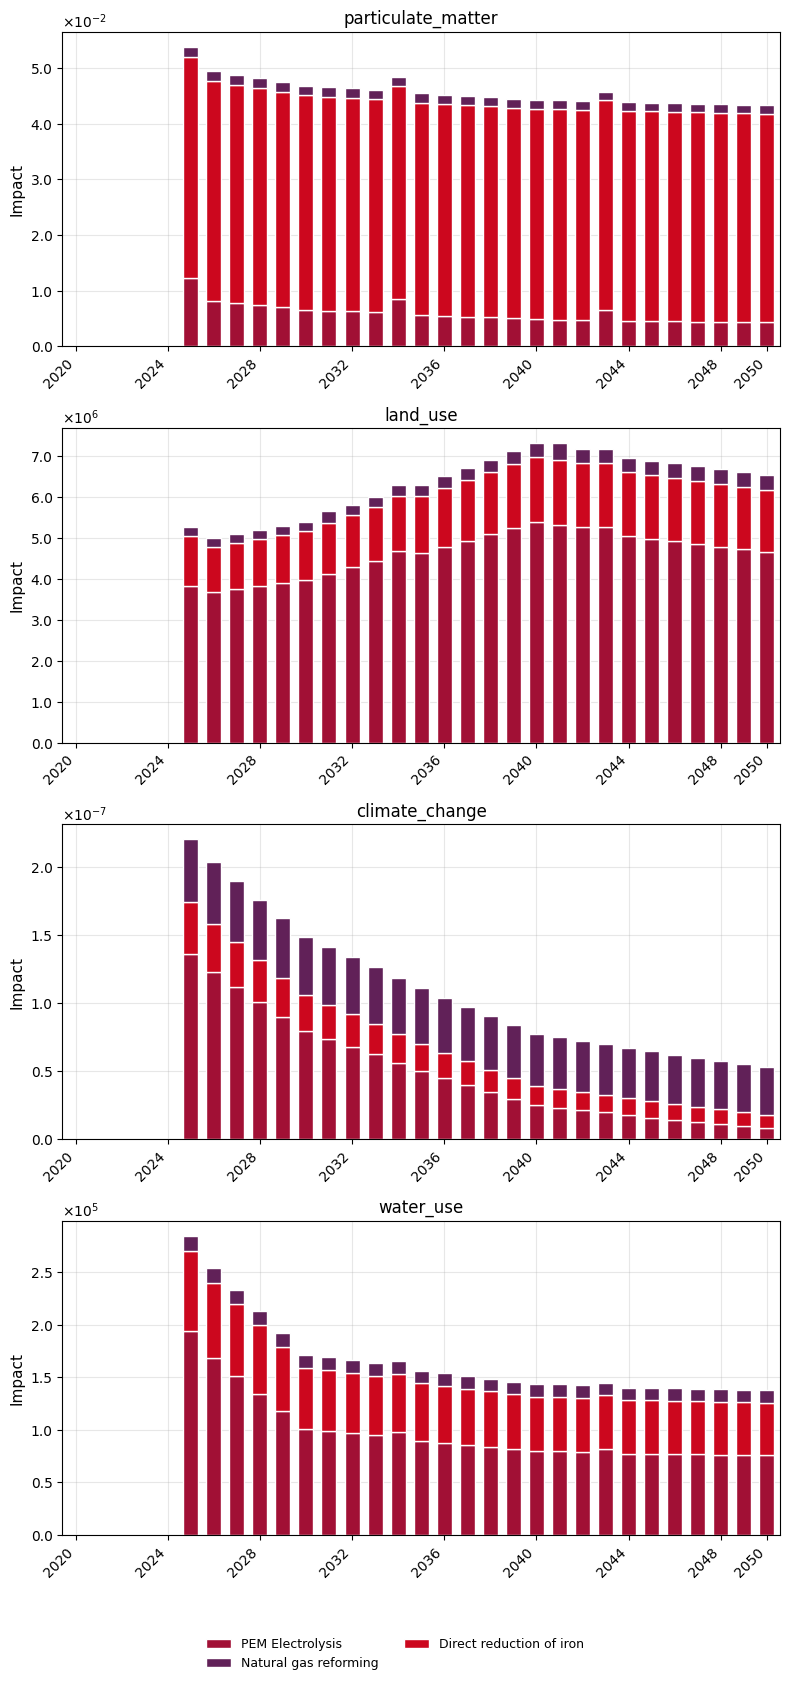

In [40]:
pp_cost_only.plot_impacts()

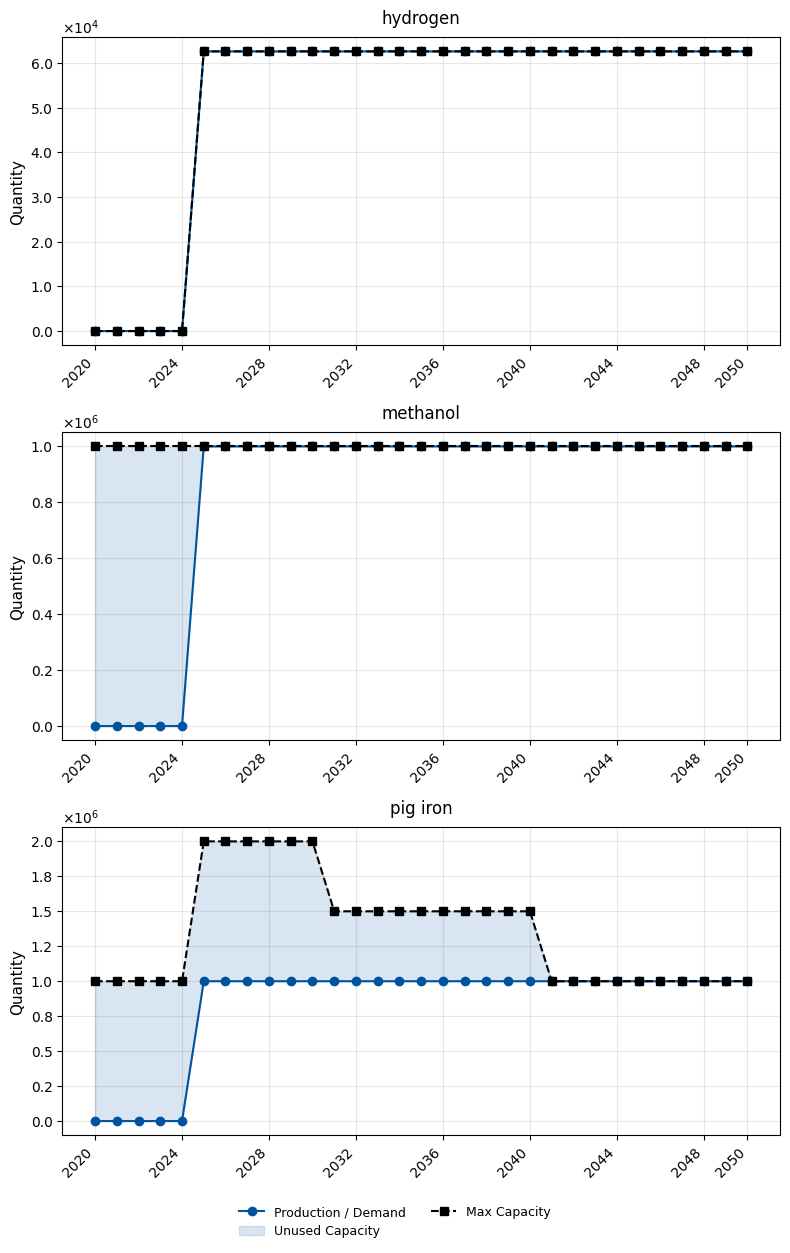

In [41]:
pp_cost_only.plot_capacity_balance()

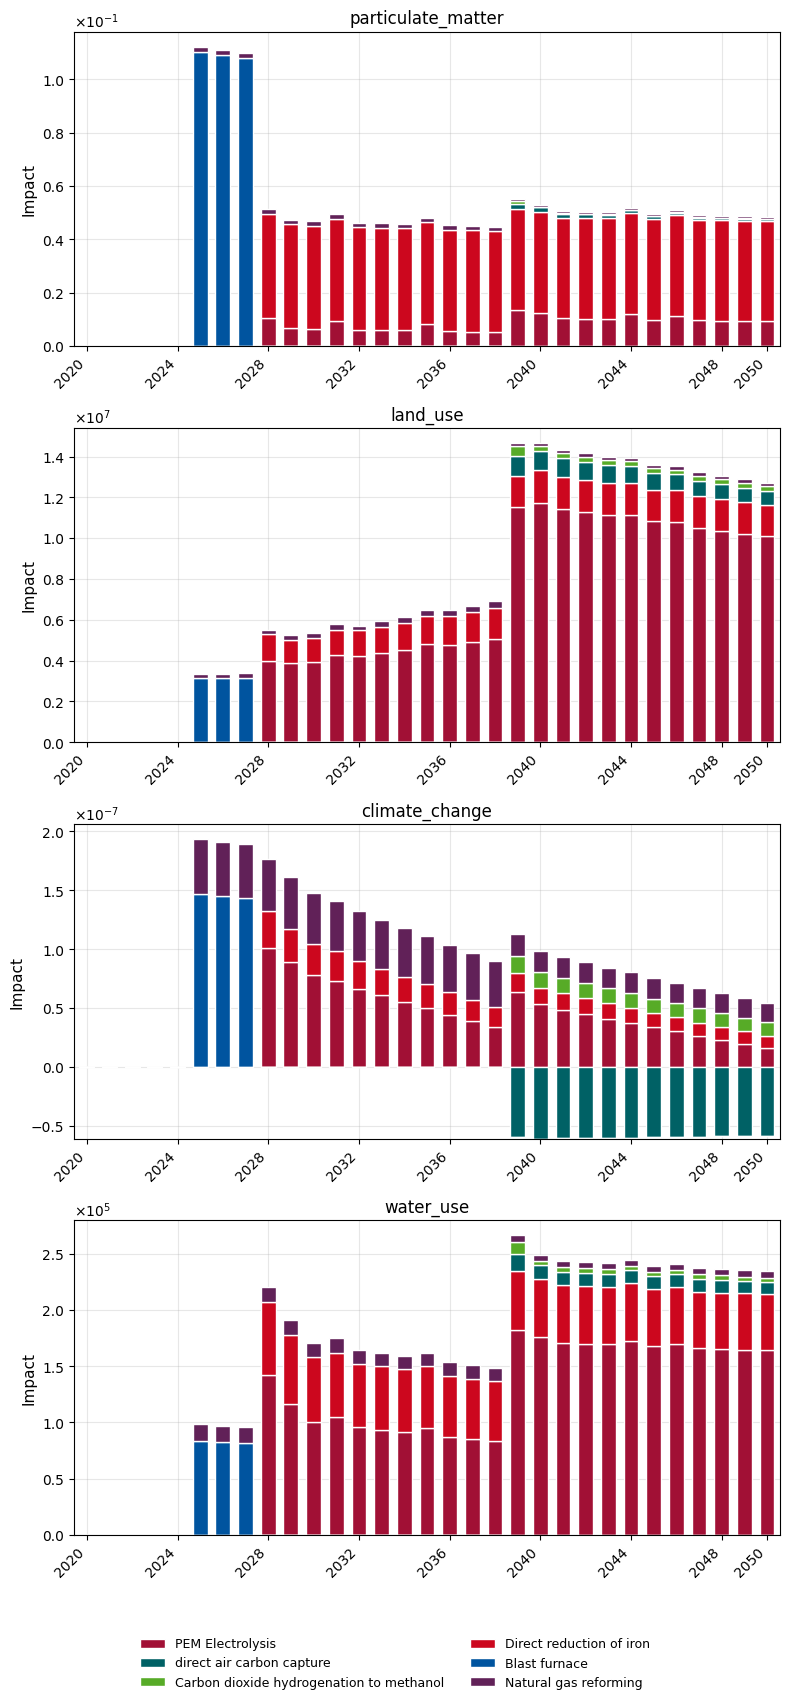

In [42]:
pp_cost_constrained.plot_impacts()

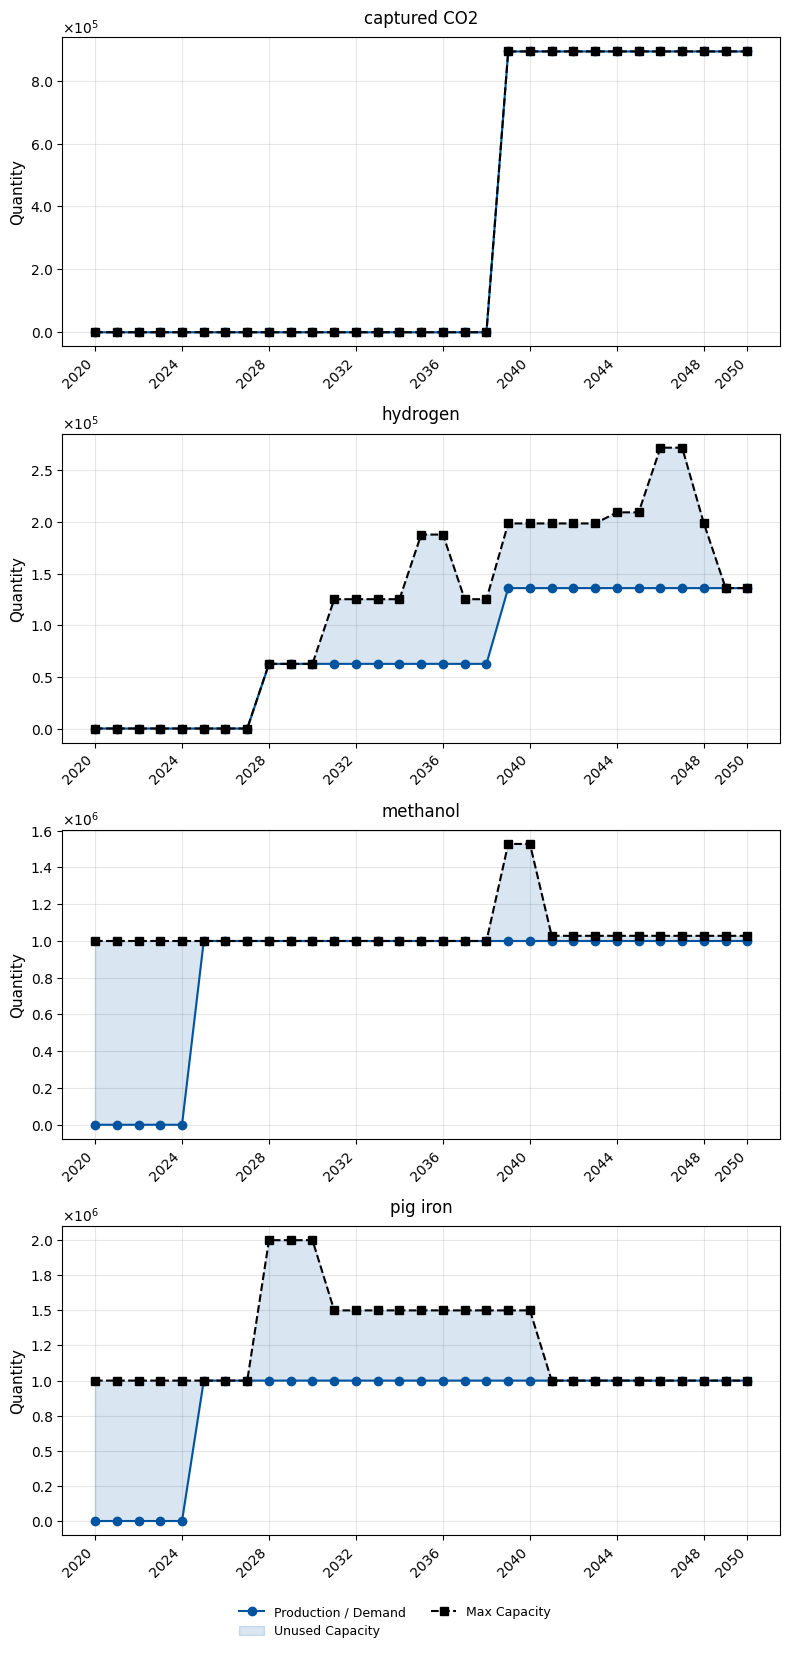

In [43]:
pp_cost_constrained.plot_capacity_balance()